<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/borges/RA2_LAB3/experiencia%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detección few-shot del **Urutaú** en grabaciones de selva 🦉
### Laboratorio 3 — *Inteligencia Computacional* (Experiencia 3)


## 1. Instalación y Configuración

In [1]:
# --- Instalación de dependencias ---
!pip -q install gdown librosa tensorflow_hub kagglehub scikit-learn soundfile matplotlib

In [2]:
# --- Imports globales ---
import os, glob, zipfile, random, time
import numpy as np
import librosa, librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_hub as hub
import gdown

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [3]:
# --- Descarga automática del dataset desde Google Drive ---
FILE_ID  = "153nCEvBj67NxYt0J7DpsNBEjSAwL7LRK"   # id del enlace provisto
ZIP_PATH = "dataset.zip"
DATA_DIR = "dataset"

if not os.path.exists(ZIP_PATH):
    gdown.download(id=FILE_ID, output=ZIP_PATH, quiet=False)

if not os.path.isdir(DATA_DIR):
    os.makedirs(DATA_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(DATA_DIR)

print("Contenido extraído:")
for root, _, files in os.walk(DATA_DIR):
    for f in files:
        print(" ", os.path.join(root, f))

Downloading...
From (original): https://drive.google.com/uc?id=153nCEvBj67NxYt0J7DpsNBEjSAwL7LRK
From (redirected): https://drive.google.com/uc?id=153nCEvBj67NxYt0J7DpsNBEjSAwL7LRK&confirm=t&uuid=87991796-cdbf-4073-a474-e911762a7fe5
To: /content/dataset.zip
100%|██████████| 379M/379M [00:08<00:00, 47.3MB/s]


Contenido extraído:
  dataset/objetivo/urutau1.jpg
  dataset/objetivo/firma_objetivo.mp3
  dataset/lotes_procesar/BO-03_OBBA-7_20191009_174300 .mp3
  dataset/lotes_procesar/BO-01_OBBA-4_20191010_054900 .mp3
  dataset/lotes_procesar/BO-07_OBBA-20_20191024_002100 .mp3
  dataset/lotes_procesar/BO-07_OBBA-20_20191022_195000 .mp3
  dataset/lotes_procesar/BO-07_OBBA-20_20191020_065900 .mp3
  dataset/lotes_procesar/BO-07_OBBA-20_20191017_174700 .mp3
  dataset/lotes_procesar/BO-04_OBBA-12_20191009_211300 .mp3
  dataset/lotes_procesar/BO-07_OBBA-20_20191022_002000 .mp3
  dataset/lotes_procesar/BO-06_OBBA-10_20191011_174400 .mp3
  dataset/lotes_procesar/BO-03_OBBA-7_20191009_182300 .mp3
  dataset/lotes_procesar/BO-07_OBBA-20_20191023_183100 .mp3
  dataset/lotes_procesar/BO-01_OBBA-4_20191010_001300 .mp3
  dataset/lotes_procesar/BO-02_OBBA-5_20191009_194300 .mp3
  dataset/lotes_procesar/BO-02_OBBA-5_20191010_062900 .mp3
  dataset/lotes_procesar/BO-07_OBBA-20_20191024_045500 .mp3
  dataset/lotes_p

In [4]:
# --- Inventario de audios: identificamos referencia (corto) vs campo (largos) ---
AUDIO_EXT = (".wav", ".mp3", ".flac", ".ogg", ".m4a")
audio_files = [p for p in glob.glob(os.path.join(DATA_DIR, "**", "*"), recursive=True)
               if p.lower().endswith(AUDIO_EXT)]

durations = []
for p in audio_files:
    try:
        d = librosa.get_duration(path=p)
    except Exception:
        d = float("nan")
    durations.append((p, d))

durations.sort(key=lambda x: x[1])   # más corto primero
print("Archivo | Duración (s)")
for p, d in durations:
    print(f"  {os.path.basename(p):40s} {d:8.1f}")

# Heurística: el más corto es la REFERENCIA con los 3 cantos; el resto, audios de campo.
REFERENCE_AUDIO = durations[0][0]
LONG_AUDIOS     = [p for p, _ in durations[1:]]

print("\n>> REFERENCIA:", REFERENCE_AUDIO)
print(">> AUDIOS DE CAMPO:", [os.path.basename(p) for p in LONG_AUDIOS])

Archivo | Duración (s)
  firma_objetivo.mp3                           36.0
  BO-03_OBBA-7_20191009_174300 .mp3           600.1
  BO-01_OBBA-4_20191010_054900 .mp3           600.1
  BO-07_OBBA-20_20191024_002100 .mp3          600.1
  BO-07_OBBA-20_20191022_195000 .mp3          600.1
  BO-07_OBBA-20_20191020_065900 .mp3          600.1
  BO-07_OBBA-20_20191017_174700 .mp3          600.1
  BO-04_OBBA-12_20191009_211300 .mp3          600.1
  BO-07_OBBA-20_20191022_002000 .mp3          600.1
  BO-06_OBBA-10_20191011_174400 .mp3          600.1
  BO-03_OBBA-7_20191009_182300 .mp3           600.1
  BO-07_OBBA-20_20191023_183100 .mp3          600.1
  BO-01_OBBA-4_20191010_001300 .mp3           600.1
  BO-02_OBBA-5_20191009_194300 .mp3           600.1
  BO-02_OBBA-5_20191010_062900 .mp3           600.1
  BO-07_OBBA-20_20191024_045500 .mp3          600.1
  BO-06_OBBA-10_20191012_001400 .mp3          600.1
  BO-06_OBBA-10_20191014_062500 .mp3          600.1
  BO-01_OBBA-4_20191010_062900 .mp3      

## 2. Preprocesamiento y Análisis de Entrada



In [5]:
# --- Constantes de formato exigidas por el modelo ---
TARGET_SR      = 32000              # 32 kHz obligatorio
WINDOW_SEC     = 5                  # ventanas de 5 s
WINDOW_SAMPLES = TARGET_SR * WINDOW_SEC   # 160000 muestras

# --- Carga del modelo base (Google Bird Vocalization Classifier) ---
MODEL_URL = ("https://www.kaggle.com/models/google/bird-vocalization-classifier/"
             "frameworks/TensorFlow2/variations/bird-vocalization-classifier/versions/8")
try:
    model = hub.load(MODEL_URL)
    print("Modelo cargado vía tensorflow_hub.")
except Exception as e:
    print("hub.load directo falló, intento con kagglehub:", e)
    import kagglehub
    local = kagglehub.model_download(
        "google/bird-vocalization-classifier/tensorFlow2/bird-vocalization-classifier")
    model = hub.load(local)
    print("Modelo cargado vía kagglehub desde:", local)

Modelo cargado vía tensorflow_hub.


In [6]:
# --- Utilidades de formato ---
def load_audio(path, sr=TARGET_SR):
    """Carga un audio como mono a la frecuencia objetivo (float32)."""
    y, _ = librosa.load(path, sr=sr, mono=True)
    return y.astype(np.float32)

def pad_or_crop(y, n=WINDOW_SAMPLES):
    """Lleva una señal a exactamente n muestras (centra y rellena con ceros, o recorta)."""
    y = np.asarray(y, dtype=np.float32)
    if len(y) >= n:
        return y[:n]
    out = np.zeros(n, dtype=np.float32)
    start = (n - len(y)) // 2
    out[start:start + len(y)] = y
    return out

def get_embedding(audio_5s):
    """Devuelve (embedding[1280], logits) para una ventana de 5 s ya formateada."""
    x = pad_or_crop(audio_5s)[np.newaxis, :].astype(np.float32)
    out = model.infer_tf(x)
    # El modelo puede devolver (logits, embeddings), dict o un objeto estructurado.
    if isinstance(out, (list, tuple)):
        logits, emb = out[0], out[1]
    elif isinstance(out, dict):
        emb    = out.get("embedding", out.get("embeddings"))
        logits = out.get("label", out.get("logits"))
    else:
        emb    = getattr(out, "embedding", None)
        logits = getattr(out, "logits", None)
    return np.asarray(emb)[0], (np.asarray(logits)[0] if logits is not None else None)

# Prueba rápida de dimensionalidad
_emb, _ = get_embedding(np.zeros(WINDOW_SAMPLES, dtype=np.float32))
print("Dimensión del embedding:", _emb.shape)

Dimensión del embedding: (1280,)


## 3. Segmentación y Data Augmentation

In [7]:
# --- Segmentación de los 3 cantos del Urutaú ---
from scipy.signal import butter, sosfiltfilt

ref = load_audio(REFERENCE_AUDIO)
print(f"Duración de la referencia: {len(ref)/TARGET_SR:.1f} s")

N_CALLS = 3              #Cantidad de cantos
WIN_SEC = 4.0            # duración del recorte alrededor de cada canto (< 5 s; se padea luego)
BAND    = (600, 2800)    # banda aproximada del canto del Urutaú (Hz)

def clip_around(center_sec, win_sec=WIN_SEC):
    """Recorta una ventana centrada en center_sec (segundos)."""
    half = int(win_sec * TARGET_SR / 2)
    c = int(center_sec * TARGET_SR)
    return ref[max(0, c - half): min(len(ref), c + half)]

# ===== OPCIÓN 1 - marcar los cantos A MANO =====
# Mirá el espectrograma que se grafica abajo, identificá los 3 silbidos descendentes y
# poné acá sus tiempos de INICIO en segundos.
MANUAL_STARTS = [6, 13.6, 26.3]         # p. ej. [6.0, 13.5, 26.0]

if MANUAL_STARTS is not None:
    centers = [s + WIN_SEC / 2 for s in MANUAL_STARTS]
else:
    # ===== OPCIÓN 2 -detección automática por SALIENCY TONAL =====
    # La energía cruda falla porque agarra transitorios fuertes (no tonales). El canto del
    # Urutaú es TONAL y vive en BAND. Saliency = energía en esa banda * tonalidad
    # (1 - planitud espectral). Así priorizamos silbidos sobre ruido de banda ancha.
    hop = 512
    sos = butter(4, BAND, btype="band", fs=TARGET_SR, output="sos")
    ref_band = sosfiltfilt(sos, ref).astype(np.float32)
    rms  = librosa.feature.rms(y=ref_band, hop_length=hop)[0]
    flat = librosa.feature.spectral_flatness(y=ref, hop_length=hop)[0]
    saliency = rms * (1.0 - flat)
    saliency = np.convolve(saliency, np.ones(15) / 15, mode="same")   # suavizado
    frame_times = librosa.frames_to_time(np.arange(len(saliency)), sr=TARGET_SR, hop_length=hop)

    centers = []
    for idx in np.argsort(saliency)[::-1]:
        t = frame_times[idx]
        if all(abs(t - c) >= WIN_SEC for c in centers):   # picos separados al menos WIN_SEC
            centers.append(t)
        if len(centers) == N_CALLS:
            break
    centers = sorted(float(c) for c in centers)

clips = [clip_around(c) for c in centers]
print(f"Cantos segmentados: {len(clips)}  (centros ≈ {[round(c, 1) for c in centers]} s)")
for i, c in enumerate(clips):
    print(f"  Canto {i+1}: {len(c)/TARGET_SR:.2f} s")

Duración de la referencia: 36.0 s
Cantos segmentados: 3  (centros ≈ [8.0, 15.6, 28.3] s)
  Canto 1: 4.00 s
  Canto 2: 4.00 s
  Canto 3: 4.00 s


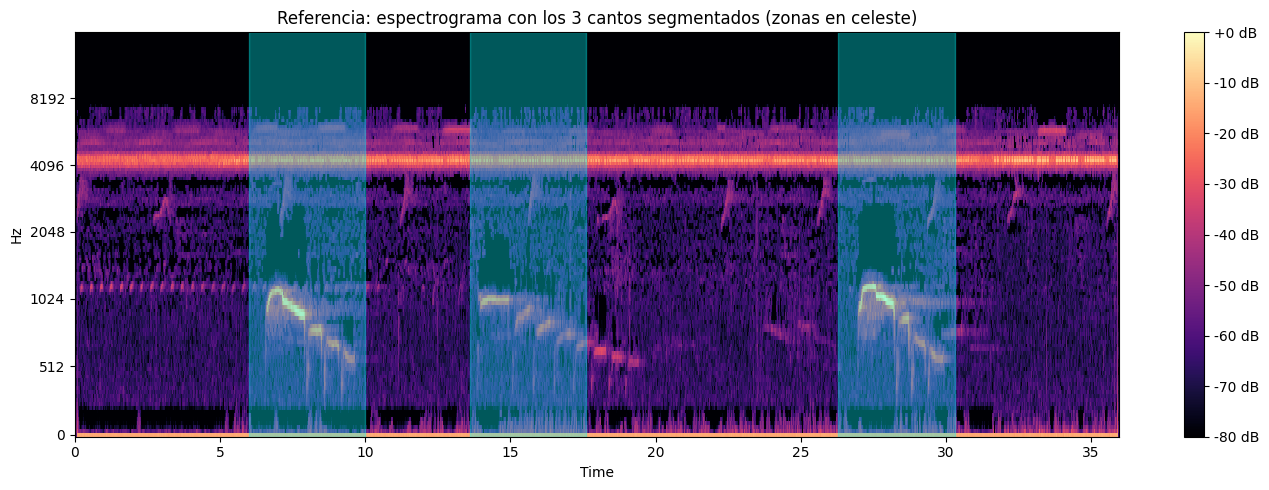

In [8]:
# --- Espectrograma de la referencia con los cantos marcados ---
S = librosa.feature.melspectrogram(y=ref, sr=TARGET_SR, n_mels=128)
S_db = librosa.power_to_db(S, ref=np.max)
plt.figure(figsize=(14, 5))
librosa.display.specshow(S_db, sr=TARGET_SR, x_axis="time", y_axis="mel", cmap="magma")
for c in centers:
    plt.axvspan(c - WIN_SEC / 2, c + WIN_SEC / 2, color="cyan", alpha=0.35)
plt.colorbar(format="%+2.0f dB")
plt.title("Referencia: espectrograma con los 3 cantos segmentados (zonas en celeste)")
plt.tight_layout(); plt.show()

In [9]:
# --- Funciones de Data Augmentation ---
def add_white_noise(y, snr_db):
    rms_sig = np.sqrt(np.mean(y**2)) + 1e-9
    rms_noise = rms_sig / (10 ** (snr_db / 20))
    noise = np.random.normal(0, rms_noise, len(y)).astype(np.float32)
    return (y + noise).astype(np.float32)

def time_stretch(y, rate):
    return librosa.effects.time_stretch(y, rate=rate).astype(np.float32)

def pitch_shift(y, n_steps, sr=TARGET_SR):
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps).astype(np.float32)

def change_gain(y, gain_db):
    return (y * (10 ** (gain_db / 20))).astype(np.float32)

def augment_clip(clip, n_random=12):
    """Genera variantes a partir de un canto original (incluye el original).
    Combina deterministas + aleatorias para ampliar el banco de positivos."""
    variants = [clip]
    # --- Deterministas ---
    for snr in (25, 15, 8):
        variants.append(add_white_noise(clip, snr))
    for rate in (0.85, 0.92, 1.08, 1.15):
        variants.append(time_stretch(clip, rate))
    for steps in (-3, -2, -1, 1, 2, 3):
        variants.append(pitch_shift(clip, steps))
    for g in (-8, -4, 4, 8):
        variants.append(change_gain(clip, g))
    # --- Combinaciones aleatorias (encadenan varias transformaciones) ---
    for _ in range(n_random):
        v = clip.copy()
        if np.random.rand() < 0.7: v = pitch_shift(v, np.random.uniform(-3, 3))
        if np.random.rand() < 0.7: v = time_stretch(v, np.random.uniform(0.85, 1.15))
        if np.random.rand() < 0.8: v = add_white_noise(v, np.random.uniform(5, 25))
        if np.random.rand() < 0.5: v = change_gain(v, np.random.uniform(-8, 8))
        variants.append(v.astype(np.float32))
    return variants

In [10]:
# --- Banco de positivos: augmentation + extracción de embeddings ---
pos_embeddings = []
pos_groups     = []
for canto_id, clip in enumerate(clips):
    for v in augment_clip(clip):
        emb, _ = get_embedding(v)          # pad_or_crop a 5 s se hace dentro
        pos_embeddings.append(emb)
        pos_groups.append(canto_id)

pos_embeddings = np.vstack(pos_embeddings)
pos_groups     = np.array(pos_groups)
print("Embeddings positivos:", pos_embeddings.shape,
      "| cantos distintos:", np.unique(pos_groups).tolist())

Embeddings positivos: (90, 1280) | cantos distintos: [0, 1, 2]


## 4. Definición de la Estrategia Few-Shot

In [11]:
TARGET_NEG = 2500     # cantidad total de negativos a muestrear

def sample_negatives(paths, target_total=TARGET_NEG):
    valid = [p for p in paths if librosa.get_duration(path=p) > WINDOW_SEC]
    if not valid:
        raise RuntimeError("No hay audios de campo válidos para muestrear negativos.")
    per_file = max(1, target_total // len(valid))
    embs = []
    for path in valid:
        y = load_audio(path)
        if len(y) < WINDOW_SAMPLES:
            continue
        for _ in range(per_file):
            start = np.random.randint(0, len(y) - WINDOW_SAMPLES)
            win = y[start:start + WINDOW_SAMPLES]
            emb, _ = get_embedding(win)
            embs.append(emb)
        if len(embs) >= target_total:
            break
    return np.vstack(embs[:target_total])

neg_embeddings = sample_negatives(LONG_AUDIOS)
print("Embeddings negativos:", neg_embeddings.shape)

Embeddings negativos: (2475, 1280)


In [12]:
# --- Clasificador de DESPLIEGUE (SVM RBF) ---
# Para la inferencia real conviene entrenar con TODOS los datos disponibles.
# La evaluación honesta de generalización se hace por separado en la Sección 6.
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X = np.vstack([pos_embeddings, neg_embeddings])
y = np.concatenate([np.ones(len(pos_embeddings)), np.zeros(len(neg_embeddings))])

clf = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED))
clf.fit(X, y)
print(f"Clasificador de despliegue entrenado con {len(pos_embeddings)} positivos "
      f"y {len(neg_embeddings)} negativos.")

# --- Prototipo para similitud del coseno (criterio complementario) ---
prototype = pos_embeddings.mean(axis=0)
prototype = prototype / (np.linalg.norm(prototype) + 1e-9)

def cosine_score(emb):
    e = emb / (np.linalg.norm(emb) + 1e-9)
    return float(np.dot(e, prototype))

Clasificador de despliegue entrenado con 90 positivos y 2475 negativos.


## 5. Inferencia en Audios de Campo (Ventana Deslizante)

In [13]:
# --- Identificar la clase del Urutaú en el modelo base (compot1) ---
def _logits_of(win):
    x = pad_or_crop(win)[np.newaxis, :].astype(np.float32)
    out = model.infer_tf(x)
    lg = (out[0] if isinstance(out, (list, tuple))
          else out.get("label", out.get("logits")) if isinstance(out, dict)
          else getattr(out, "logits"))
    return np.asarray(lg)[0]

tops = [int(np.argmax(_logits_of(c))) for c in clips]
POTOO_IDX = max(set(tops), key=tops.count)     # clase que domina los 3 cantos

LABELS = None        # (opcional) nombres de clase, si encontramos el CSV de etiquetas
try:
    import pandas as pd
    for c in set(glob.glob('/tmp/tfhub_modules/**/*.csv', recursive=True) +
                 glob.glob('/root/.cache/kagglehub/**/*.csv', recursive=True)):
        df = pd.read_csv(c)
        if len(df) > 5000:
            LABELS = df.iloc[:, 0].astype(str).tolist(); break
except Exception:
    pass
nombre = LABELS[POTOO_IDX] if (LABELS and POTOO_IDX < len(LABELS)) else "?"
print(f"Clase del Urutaú -> índice {POTOO_IDX} ({nombre}) | argmax por canto: {tops}")

Clase del Urutaú -> índice 2616 (compot1) | argmax por canto: [2616, 2616, 2616]


In [14]:
# --- Inferencia OPTIMIZADA: batching + streaming + CACHÉ DE EMBEDDINGS Y LOGIT ---
import gc

BATCH      = 64        # ventanas enviadas juntas al modelo
HOP_SEC    = 1.5       # paso de la ventana deslizante
THRESHOLD  = 0.45      # umbral sobre la probabilidad del SVM
COS_THRESH = None      # None = no usar el coseno como filtro duro (mejora el recall)

def _extract_emb(out):
    if isinstance(out, (list, tuple)): return np.asarray(out[1])
    if isinstance(out, dict):          return np.asarray(out.get("embedding", out.get("embeddings")))
    return np.asarray(getattr(out, "embedding"))

def _extract_logits(out):
    return np.asarray(out[0] if isinstance(out, (list, tuple))
                      else out.get("label", out.get("logits")) if isinstance(out, dict)
                      else getattr(out, "logits"))

def scan_embeddings(path, hop_sec=HOP_SEC):
    """Pasa el modelo UNA vez y devuelve (starts, emb[float16], logit_urutau[float32])."""
    y = load_audio(path)
    hop = int(hop_sec * TARGET_SR)
    starts = list(range(0, max(1, len(y) - WINDOW_SAMPLES + 1), hop))
    out_emb = np.empty((len(starts), 1280), dtype=np.float16)
    out_lg  = np.empty(len(starts), dtype=np.float32)
    for i in range(0, len(starts), BATCH):
        bs = starts[i:i + BATCH]
        chunk = np.zeros((BATCH, WINDOW_SAMPLES), dtype=np.float32)
        for j, s in enumerate(bs):
            chunk[j] = y[s:s + WINDOW_SAMPLES]
        out = model.infer_tf(chunk)
        out_emb[i:i + len(bs)] = _extract_emb(out)[:len(bs)].astype(np.float16)
        out_lg[i:i + len(bs)]  = _extract_logits(out)[:len(bs), POTOO_IDX]
    del y; gc.collect()
    return np.array(starts, dtype=np.int64), out_emb, out_lg

def score_windows(emb16):
    """Puntúa embeddings cacheados con el clf y prototipo ACTUALES (globals)."""
    e = emb16.astype(np.float32)
    probs = clf.predict_proba(e)[:, 1]
    cos   = (e @ prototype) / (np.linalg.norm(e, axis=1) + 1e-9)
    return probs, cos

def events_for(path, threshold=THRESHOLD, cos_thresh=COS_THRESH, hop_sec=HOP_SEC):
    """Detección por SVM, usando los embeddings cacheados (barato)."""
    starts = START_CACHE[path]
    probs, cos = score_windows(EMB_CACHE[path])
    events = []
    for k, st in enumerate(starts):
        t = st / TARGET_SR; p = float(probs[k]); c = float(cos[k])
        if p < threshold:                              continue
        if cos_thresh is not None and c < cos_thresh:  continue
        if events and t - events[-1]["fin"] <= hop_sec + 0.01:
            events[-1]["fin"] = float(t + WINDOW_SEC)
            events[-1]["prob_max"] = max(events[-1]["prob_max"], p)
        else:
            events.append({"inicio": float(t), "fin": float(t + WINDOW_SEC), "prob_max": p})
    return events

In [15]:
# --- Escaneo de TODOS los audios: se cachean embeddings + logit del Urutaú ---
EMB_CACHE   = {}     # path -> embeddings float16 (n_ventanas, 1280)
START_CACHE = {}     # path -> starts en muestras
LOGIT_CACHE = {}     # path -> logit de la clase Urutaú por ventana (float32)
for k, path in enumerate(LONG_AUDIOS, 1):
    try:
        st, emb, lg = scan_embeddings(path)
        START_CACHE[path] = st; EMB_CACHE[path] = emb; LOGIT_CACHE[path] = lg
        if k % 20 == 0 or k == len(LONG_AUDIOS):
            mb = sum(e.nbytes for e in EMB_CACHE.values()) / 1e6
            print(f"[{k:3d}/{len(LONG_AUDIOS)}] cacheados | caché ≈ {mb:.0f} MB")
    except Exception as e:
        print(f"[{k:3d}/{len(LONG_AUDIOS)}] ERROR {os.path.basename(path)}: {e}")
print("\nListo. Cacheados embeddings + logit: reentrenar o cambiar umbral ya NO re-corre el modelo.")

[ 20/165] cacheados | caché ≈ 20 MB
[ 40/165] cacheados | caché ≈ 41 MB
[ 60/165] cacheados | caché ≈ 61 MB
[ 80/165] cacheados | caché ≈ 81 MB
[100/165] cacheados | caché ≈ 102 MB
[120/165] cacheados | caché ≈ 122 MB
[140/165] cacheados | caché ≈ 142 MB
[160/165] cacheados | caché ≈ 163 MB
[165/165] cacheados | caché ≈ 168 MB

Listo. Cacheados embeddings + logit: reentrenar o cambiar umbral ya NO re-corre el modelo.


## 6. Resultados, Logs y Métricas

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y)
clf_naive = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED))
clf_naive.fit(X_tr, y_tr)

print("=" * 60)
print("(A) VALIDACIÓN NAIVE CON FUGA DE DATOS  —  OPTIMISTA, NO CONFIAR")
print("=" * 60)
print(classification_report(y_val, clf_naive.predict(X_val),
                            target_names=["Fondo", "Urutaú"], zero_division=0))
print("Matriz de confusión:\n", confusion_matrix(y_val, clf_naive.predict(X_val)))

(A) VALIDACIÓN NAIVE CON FUGA DE DATOS  —  OPTIMISTA, NO CONFIAR
              precision    recall  f1-score   support

       Fondo       1.00      1.00      1.00       619
      Urutaú       1.00      1.00      1.00        23

    accuracy                           1.00       642
   macro avg       1.00      1.00      1.00       642
weighted avg       1.00      1.00      1.00       642

Matriz de confusión:
 [[619   0]
 [  0  23]]


In [17]:
# --- (B) Evaluación HONESTA: Leave-One-Canto-Out ---
from sklearn.model_selection import LeaveOneGroupOut

half = len(neg_embeddings) // 2          # mitad de negativos a train, mitad a val (sin solapar)
logo = LeaveOneGroupOut()

print("=" * 60)
print("(B) VALIDACIÓN HONESTA  —  LEAVE-ONE-CANTO-OUT")
print("=" * 60)

if len(np.unique(pos_groups)) < 2:
    print("\n⚠️  Hay menos de 2 cantos segmentados (grupos:",
          np.unique(pos_groups).tolist(), ").")
    print("    No se puede hacer Leave-One-Canto-Out: volvé a la Sección 3 y asegurate")
    print("    de aislar los 3 cantos (usá MANUAL_STARTS mirando el espectrograma).")
else:
    recalls = []
    for tr_idx, va_idx in logo.split(pos_embeddings, groups=pos_groups):
        Xtr = np.vstack([pos_embeddings[tr_idx], neg_embeddings[:half]])
        ytr = np.r_[np.ones(len(tr_idx)), np.zeros(half)]
        Xva = np.vstack([pos_embeddings[va_idx], neg_embeddings[half:]])
        yva = np.r_[np.ones(len(va_idx)), np.zeros(len(neg_embeddings) - half)]

        m = make_pipeline(
            StandardScaler(),
            SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED))
        m.fit(Xtr, ytr)
        y_hat = m.predict(Xva)
        canto = int(pos_groups[va_idx][0]) + 1
        rec = float(np.mean(y_hat[:len(va_idx)] == 1))     # recall sobre el canto retenido
        recalls.append(rec)
        print(f"\n--- Canto {canto} retenido (no visto en entrenamiento) ---")
        print(classification_report(yva, y_hat, target_names=["Fondo", "Urutaú"], zero_division=0))

    print("\n>> Recall promedio sobre cantos retenidos: "
          f"{np.mean(recalls):.2f}  (esta es la métrica REALISTA de generalización)")
    print(">> Nota: los 3 cantos pueden ser del mismo individuo y condiciones de grabación")
    print("   similares, así que ni esto es una prueba 100% independiente.")

(B) VALIDACIÓN HONESTA  —  LEAVE-ONE-CANTO-OUT

--- Canto 1 retenido (no visto en entrenamiento) ---
              precision    recall  f1-score   support

       Fondo       1.00      1.00      1.00      1238
      Urutaú       1.00      1.00      1.00        30

    accuracy                           1.00      1268
   macro avg       1.00      1.00      1.00      1268
weighted avg       1.00      1.00      1.00      1268


--- Canto 2 retenido (no visto en entrenamiento) ---
              precision    recall  f1-score   support

       Fondo       0.98      1.00      0.99      1238
      Urutaú       0.00      0.00      0.00        30

    accuracy                           0.98      1268
   macro avg       0.49      0.50      0.49      1268
weighted avg       0.95      0.98      0.96      1268


--- Canto 3 retenido (no visto en entrenamiento) ---
              precision    recall  f1-score   support

       Fondo       1.00      1.00      1.00      1238
      Urutaú       1.00     

In [18]:
# --- Estimación de la tasa de falsos positivos y sugerencia de umbral ---
# Usa el clasificador de despliegue sobre los negativos muestreados del campo.
neg_scores = clf.predict_proba(neg_embeddings)[:, 1]
fp_rate = float(np.mean(neg_scores >= THRESHOLD))
print(f"Tasa estimada de falsos positivos @ umbral {THRESHOLD}: {fp_rate:.3f}")

Tasa estimada de falsos positivos @ umbral 0.45: 0.000


In [23]:
# --- Barrido de umbral (usa la CACHÉ de embeddings: no re-corre el modelo) ---
# Te ayuda a elegir el umbral mirando cuántas detecciones aparecen en cada nivel.
print("umbral | detecciones | archivos con detección")
for th in (0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70):
    evs = {p: events_for(p, th) for p in LONG_AUDIOS}
    n_det   = sum(len(v) for v in evs.values())
    n_files = sum(1 for v in evs.values() if v)
    print(f"  {th:.2f} |    {n_det:4d}     |    {n_files:3d}")

umbral | detecciones | archivos con detección
  0.30 |      25     |      6
  0.35 |      23     |      5
  0.40 |      20     |      5
  0.45 |      18     |      5
  0.50 |      17     |      5
  0.60 |      15     |      4
  0.70 |      14     |      4


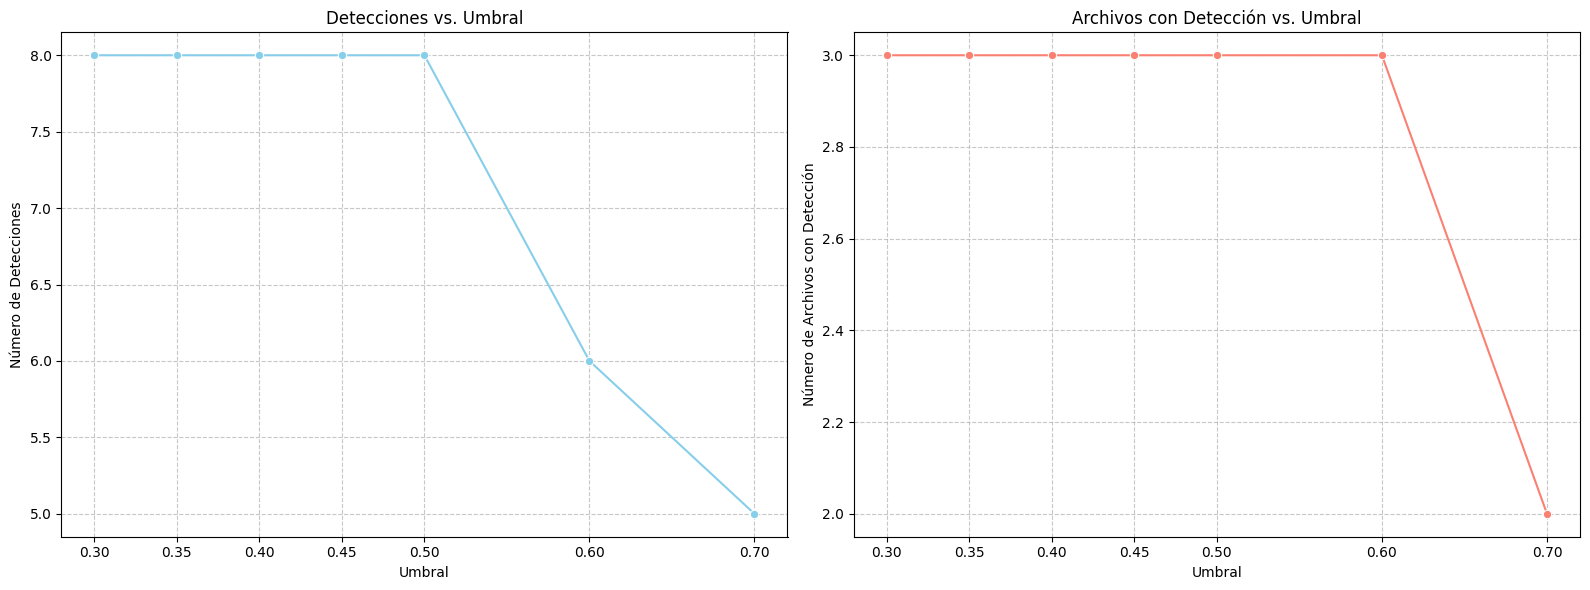

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data from the threshold sweep
data = {
    'umbral': [0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70],
    'detecciones': [8, 8, 8, 8, 8, 6, 5],
    'archivos con detección': [3, 3, 3, 3, 3, 3, 2]
}
df_threshold = pd.DataFrame(data)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for 'detecciones'
sns.lineplot(ax=axes[0], x='umbral', y='detecciones', data=df_threshold, marker='o', color='skyblue')
axes[0].set_title('Detecciones vs. Umbral')
axes[0].set_xlabel('Umbral')
axes[0].set_ylabel('Número de Detecciones')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].set_xticks(df_threshold['umbral'])

# Plot for 'archivos con detección'
sns.lineplot(ax=axes[1], x='umbral', y='archivos con detección', data=df_threshold, marker='o', color='salmon')
axes[1].set_title('Archivos con Detección vs. Umbral')
axes[1].set_xlabel('Umbral')
axes[1].set_ylabel('Número de Archivos con Detección')
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].set_xticks(df_threshold['umbral'])

plt.tight_layout()
plt.show()


=== BO-06_OBBA-10_20191012_001400 .mp3 — 1 detección(es) [grabado 00h, noche] ===
   Canto detectado en: 00:04:33  (conf=1.00, dur≈9.5s)


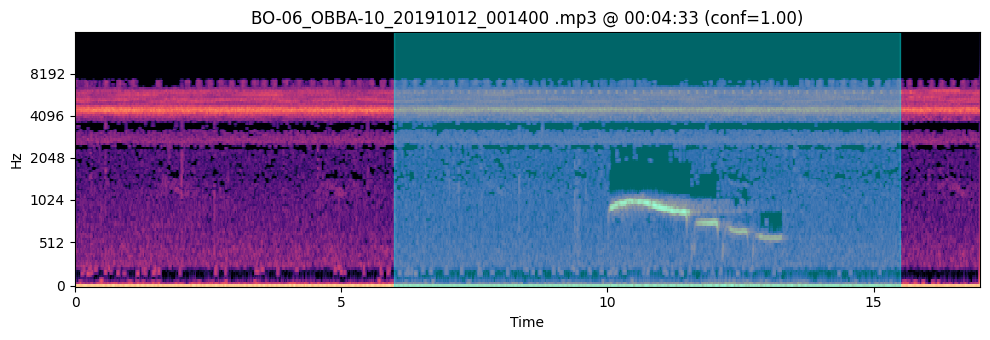


=== BO-06_OBBA-10_20191015_050400 .mp3 — 2 detección(es) [grabado 05h, noche] ===
   Canto detectado en: 00:07:04  (conf=0.49, dur≈5.0s)


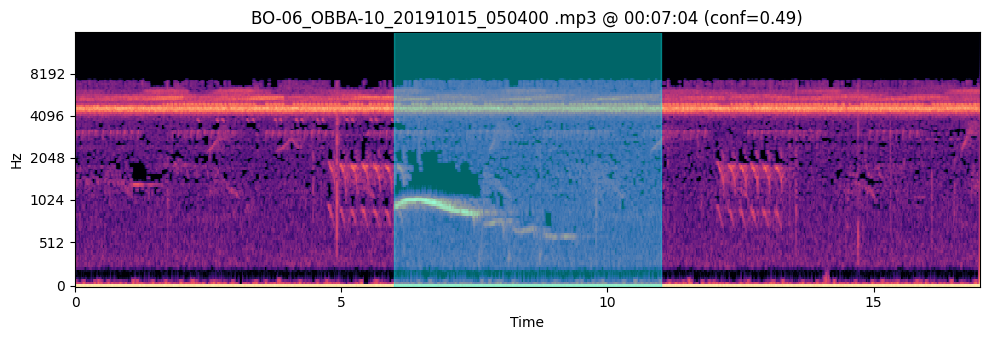

   Canto detectado en: 00:08:06  (conf=0.52, dur≈5.0s)


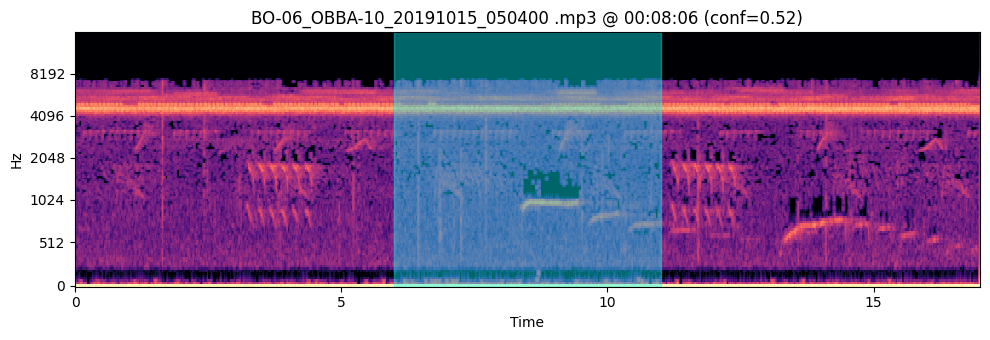


=== BO-06_OBBA-10_20191013_050600 .mp3 — 5 detección(es) [grabado 05h, noche] ===
   Canto detectado en: 00:00:51  (conf=1.00, dur≈6.5s)


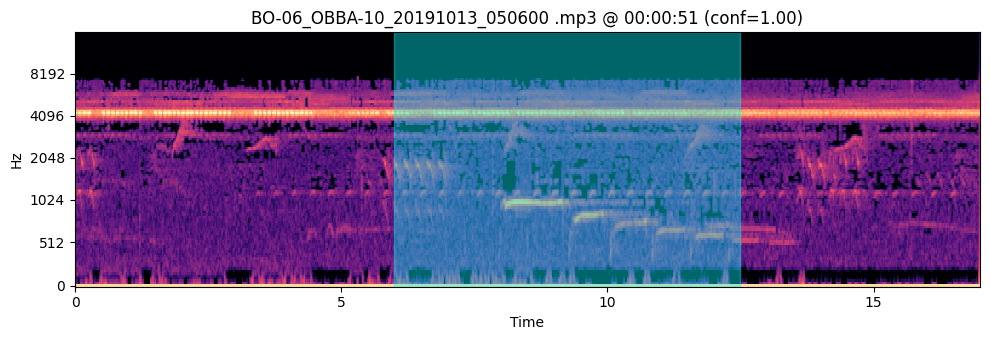

   Canto detectado en: 00:01:25  (conf=1.00, dur≈8.0s)


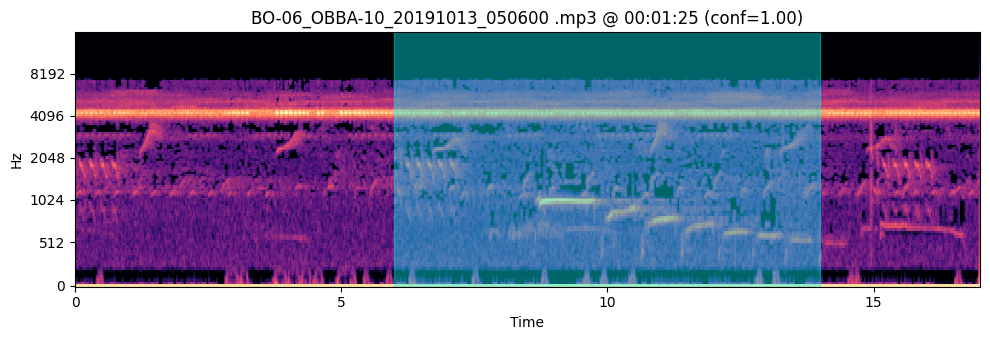

   Canto detectado en: 00:01:58  (conf=1.00, dur≈8.0s)


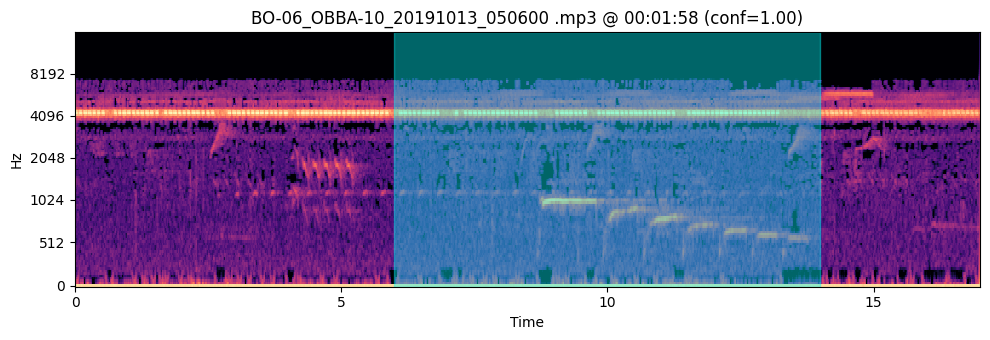

   Canto detectado en: 00:02:28  (conf=1.00, dur≈15.5s)


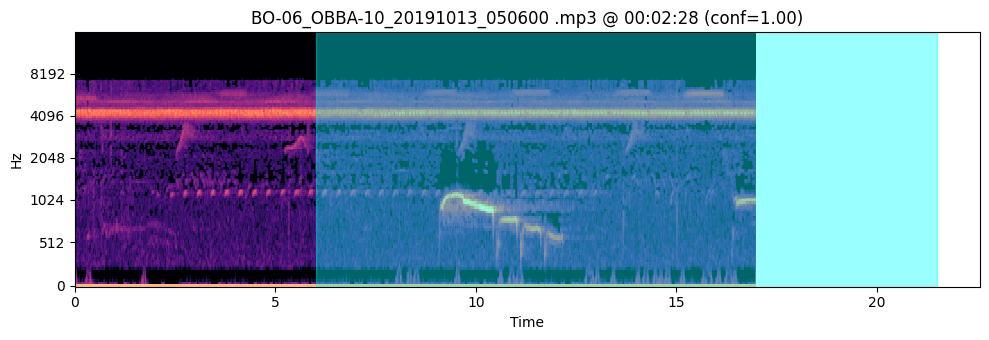

   Canto detectado en: 00:02:51  (conf=1.00, dur≈9.5s)


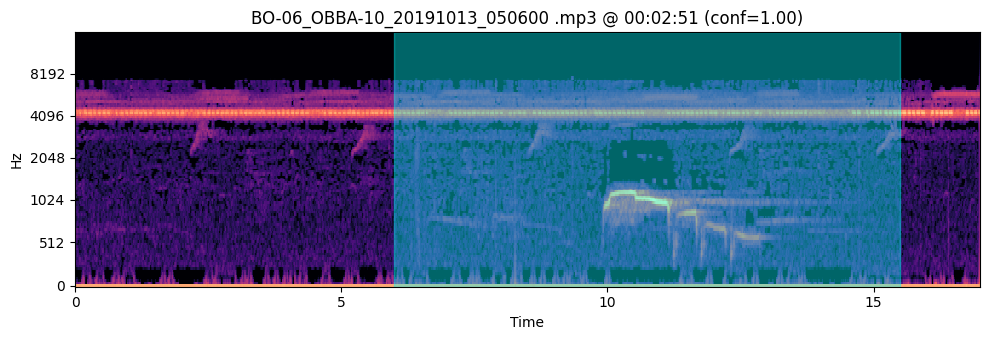


=== BO-06_OBBA-10_20191012_221500 .mp3 — 8 detección(es) [grabado 22h, noche] ===
   Canto detectado en: 00:01:09  (conf=0.67, dur≈6.5s)


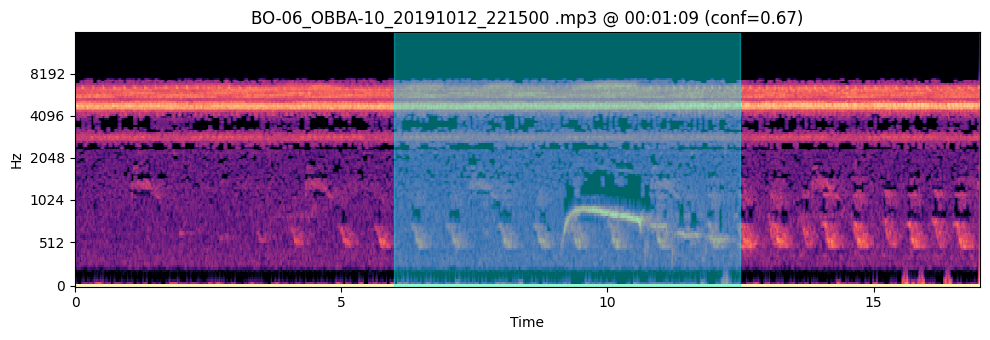

   Canto detectado en: 00:01:31  (conf=0.81, dur≈8.0s)


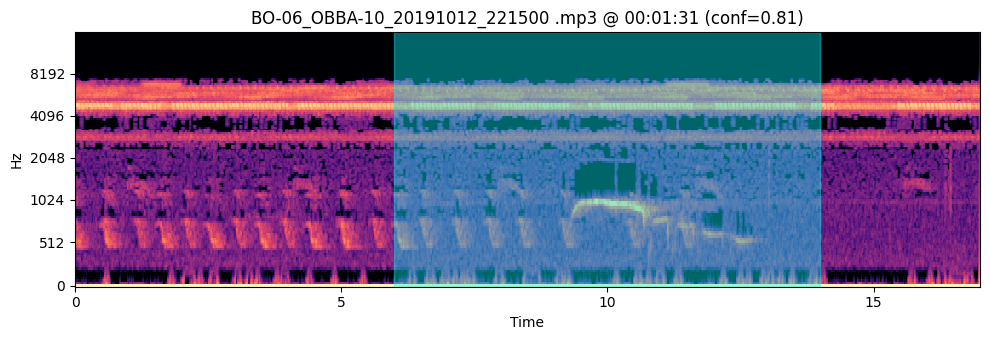

   Canto detectado en: 00:01:54  (conf=1.00, dur≈8.0s)


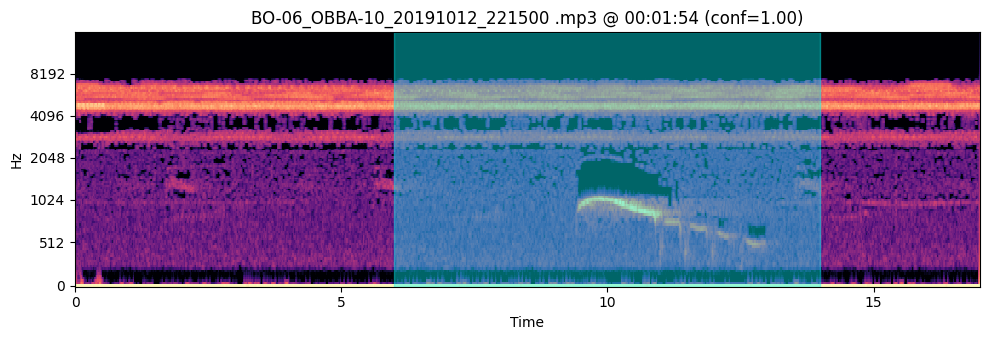

   Canto detectado en: 00:02:16  (conf=0.99, dur≈8.0s)


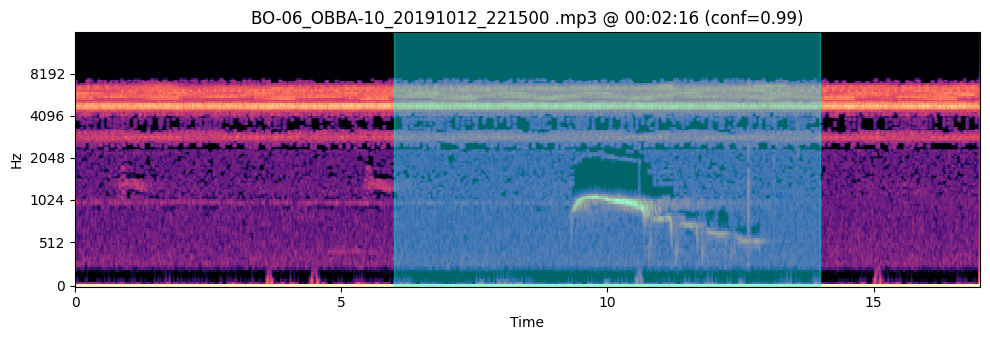

   Canto detectado en: 00:02:40  (conf=0.96, dur≈8.0s)


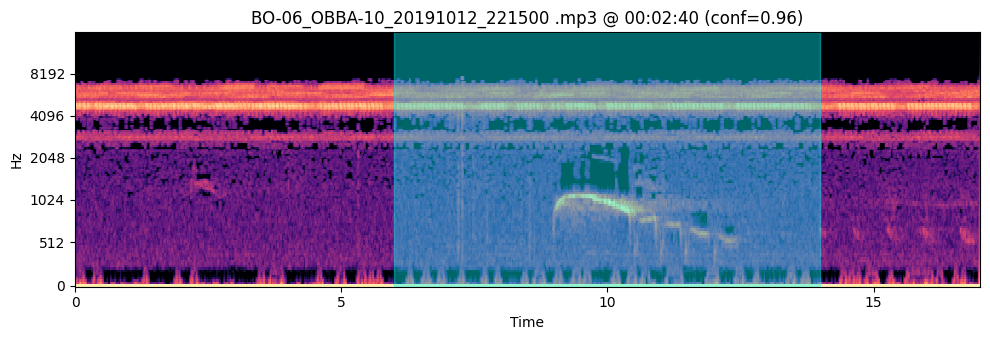

   Canto detectado en: 00:03:01  (conf=1.00, dur≈9.5s)


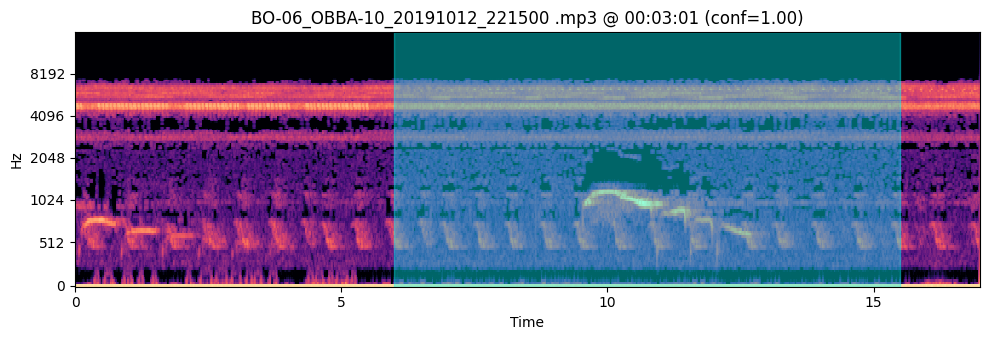

   Canto detectado en: 00:07:49  (conf=1.00, dur≈8.0s)
   Canto detectado en: 00:08:18  (conf=1.00, dur≈9.5s)

=== BO-06_OBBA-10_20191012_050700 .mp3 — 2 detección(es) [grabado 05h, noche] ===
   Canto detectado en: 00:09:10  (conf=0.59, dur≈6.5s)


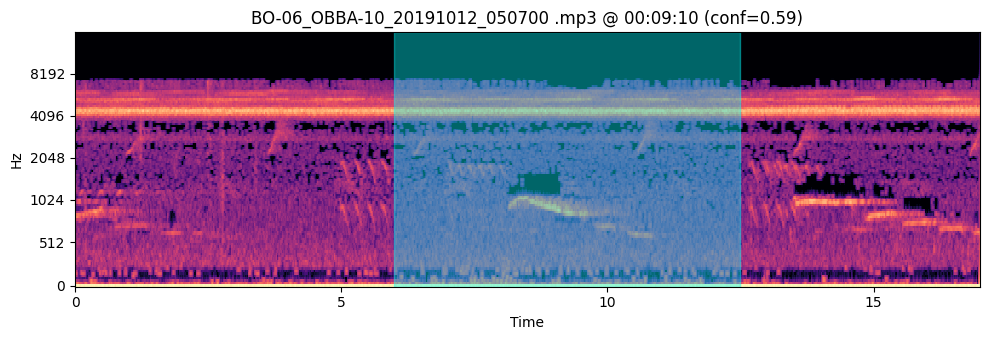

   Canto detectado en: 00:09:49  (conf=0.84, dur≈6.5s)


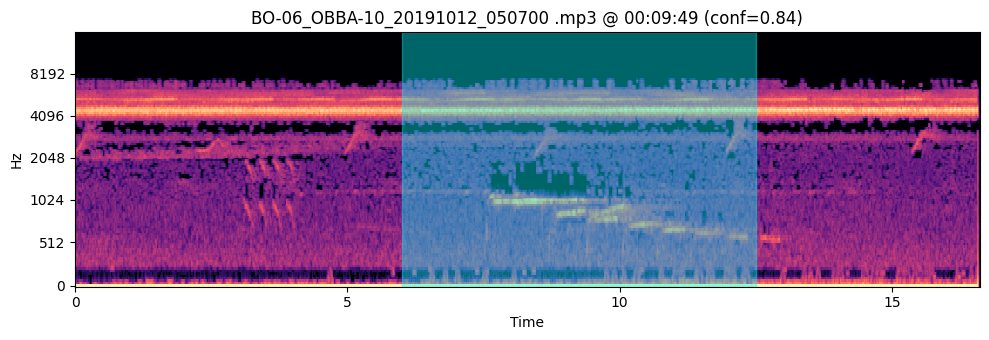


>> TOTAL de detecciones: 18  (umbral=0.45, hop=1.5s)


In [25]:
# --- Detecciones finales + espectrograma SOLO de los audios con cantos ---
import re
def fmt_time(s):
    h = int(s // 3600); m = int((s % 3600) // 60); sec = int(s % 60)
    return f"{h:02d}:{m:02d}:{sec:02d}"

def rec_hour(path):
    """Hora de grabación leída del nombre (..._YYYYMMDD_HHMMSS...). El Urutaú es nocturno."""
    m = re.search(r'_(\d{8})_(\d{6})', os.path.basename(path))
    return int(m.group(2)[:2]) if m else None

def plot_detection_segment(path, ev, pad=6.0):
    """Grafica SOLO un tramo corto alrededor de la detección (liviano en RAM)."""
    off = max(0.0, ev["inicio"] - pad)
    seg, _ = librosa.load(path, sr=TARGET_SR, offset=off,
                          duration=WINDOW_SEC + 2 * pad, mono=True)
    S = librosa.power_to_db(
        librosa.feature.melspectrogram(y=seg, sr=TARGET_SR, n_mels=128), ref=np.max)
    fig = plt.figure(figsize=(10, 3.5))
    librosa.display.specshow(S, sr=TARGET_SR, x_axis="time", y_axis="mel", cmap="magma")
    rel = ev["inicio"] - off
    plt.axvspan(rel, rel + (ev["fin"] - ev["inicio"]), color="cyan", alpha=0.4)
    plt.title(f"{os.path.basename(path)} @ {fmt_time(ev['inicio'])} (conf={ev['prob_max']:.2f})")
    plt.tight_layout(); plt.show(); plt.close(fig)        # close() libera la figura

MAX_PLOTS_PER_FILE = 6     # tope de espectrogramas por archivo (evita saturar la salida)

total = 0
for path in LONG_AUDIOS:
    events = events_for(path, THRESHOLD, COS_THRESH)
    if not events:
        continue                                          # NO graficamos audios sin detección
    h = rec_hour(path)
    franja = "noche" if (h is not None and (h >= 18 or h <= 6)) else "día"
    print(f"\n=== {os.path.basename(path)} — {len(events)} detección(es) "
          f"[grabado {h:02d}h, {franja}] ===" if h is not None
          else f"\n=== {os.path.basename(path)} — {len(events)} detección(es) ===")
    for k, ev in enumerate(events):
        print(f"   Canto detectado en: {fmt_time(ev['inicio'])}  "
              f"(conf={ev['prob_max']:.2f}, dur≈{ev['fin']-ev['inicio']:.1f}s)")
        if k < MAX_PLOTS_PER_FILE:
            plot_detection_segment(path, ev)
    total += len(events)

print(f"\n>> TOTAL de detecciones: {total}  (umbral={THRESHOLD}, hop={HOP_SEC}s)")
if total == 0:
    print(">> Si esperabas detecciones, bajá THRESHOLD (mirá el barrido de arriba) y reejecutá esta celda.")

## 7. Mejora del recall: Auto-entrenamiento (self-training)


In [22]:
# --- (7) AUTO-ENTRENAMIENTO: enriquecer positivos con cantos reales de campo ---
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

TAU_POS      = 0.80    # confianza mínima para aceptar una ventana como positivo REAL
ROUNDS       = 3       # rondas de auto-entrenamiento
MAX_PER_FILE = 15      # tope de positivos nuevos por archivo y por ronda (evita dominancia)

def _retrain(pos_set):
    Xx = np.vstack([pos_set, neg_embeddings]).astype(np.float32)
    yy = np.r_[np.ones(len(pos_set)), np.zeros(len(neg_embeddings))]
    m = make_pipeline(StandardScaler(),
                      SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED))
    m.fit(Xx, yy)
    proto = pos_set.mean(axis=0); proto = proto / (np.linalg.norm(proto) + 1e-9)
    return m, proto

pos_real  = pos_embeddings.copy().astype(np.float32)   # banco de positivos que iremos creciendo
added_idx = {p: set() for p in LONG_AUDIOS}            # para no re-agregar la misma ventana
base_det  = sum(len(events_for(p, THRESHOLD)) for p in LONG_AUDIOS)
print(f"Detecciones iniciales (umbral {THRESHOLD}): {base_det}")

for r in range(1, ROUNDS + 1):
    nuevos = []
    for path in LONG_AUDIOS:
        probs, _ = score_windows(EMB_CACHE[path])
        cand = [i for i in np.where(probs >= TAU_POS)[0] if i not in added_idx[path]]
        if not cand:
            continue
        cand = sorted(cand, key=lambda i: probs[i], reverse=True)[:MAX_PER_FILE]
        added_idx[path].update(cand)
        nuevos.append(EMB_CACHE[path][cand].astype(np.float32))
    if not nuevos:
        print(f"Ronda {r}: no hay ventanas nuevas con prob >= {TAU_POS}. Corto.")
        break
    nuevos = np.vstack(nuevos)
    pos_real = np.vstack([pos_real, nuevos])
    clf, prototype = _retrain(pos_real)                # actualiza los globals que usa events_for
    n = sum(len(events_for(p, THRESHOLD)) for p in LONG_AUDIOS)
    print(f"Ronda {r}: +{len(nuevos):3d} positivos reales (banco={len(pos_real)}) -> {n} detecciones")

print("\nclf y prototype quedaron reentrenados con positivos reales.")
print(">> Reejecutá el barrido y la celda de detecciones para ver/visualizar el resultado final.")

Detecciones iniciales (umbral 0.45): 8
Ronda 1: +  8 positivos reales (banco=98) -> 12 detecciones
Ronda 2: + 13 positivos reales (banco=111) -> 16 detecciones
Ronda 3: +  8 positivos reales (banco=119) -> 18 detecciones

clf y prototype quedaron reentrenados con positivos reales.
>> Reejecutá el barrido y la celda de detecciones para ver/visualizar el resultado final.


## 8. Logit del Urutaú + Hard-negative mining

La sonda confirmó que el modelo base **ya tiene una clase del Urutaú** (`compot1`): en los 3 cantos su logit es alto (≈ 6–11) y todo lo demás queda en negativo. Ese logit es un detector de **especie** mucho más confiable que el SVM de 3 ejemplos, y lo aprovechamos para dos cosas:

- **Confirmar/rechazar detecciones:** un canto del Urutaú dispara `compot1`; un ave *parecida* (falso positivo) no. Así el modelo nos dice solo cuáles detecciones son falsas.
- **Hard-negative mining automático:** las detecciones del SVM con logit de Urutaú **bajo** son casi seguro falsos positivos → las guardamos como negativos y reentrenamos. Sumado a los falsos positivos que cargues a mano, el SVM se va corrigiendo.

In [26]:
# --- Detección por el LOGIT de la clase Urutaú (compot1) ---
# Referencia: los 3 cantos dieron logit ~6-11; el fondo y otras aves dan logit negativo.
LOGIT_THRESH = 1.5

def events_logit(path, lthresh=LOGIT_THRESH, hop_sec=HOP_SEC):
    starts = START_CACHE[path]; lg = LOGIT_CACHE[path]; events = []
    for k, st in enumerate(starts):
        t = st / TARGET_SR
        if lg[k] < lthresh:
            continue
        if events and t - events[-1]["fin"] <= hop_sec + 0.01:
            events[-1]["fin"] = float(t + WINDOW_SEC)
            events[-1]["lmax"] = max(events[-1]["lmax"], float(lg[k]))
        else:
            events.append({"inicio": float(t), "fin": float(t + WINDOW_SEC), "lmax": float(lg[k])})
    return events

print("logit_umbral | detecciones | archivos")
for L in (0, 1, 2, 3, 4, 6):
    evs = {p: events_logit(p, L) for p in LONG_AUDIOS}
    print(f"      {L:>4}    |    {sum(len(v) for v in evs.values()):4d}     |   {sum(1 for v in evs.values() if v):3d}")

logit_umbral | detecciones | archivos
         0    |      48     |    11
         1    |      33     |     9
         2    |      26     |     6
         3    |      21     |     5
         4    |      17     |     5
         6    |      10     |     4


In [27]:
# --- HARD-NEGATIVE MINING: guardar falsos positivos y reentrenar el SVM ---
# 1) FPs MANUALES que confirmaste (subcadena del archivo, tiempo "MM:SS" / "HH:MM:SS" / seg):
FALSE_POSITIVES = [
    ("BO-06_OBBA-10_20191012_050700", "00:09:49"),   # el que compartiste
    # ("otro_archivo", "03:21"),
]
# 2) FPs AUTOMÁTICOS: detecciones del SVM que el logit del Urutaú NO confirma (logit bajo).
AUTO_FP_FROM_LOGIT = True
LOGIT_OK = 1.5     # por debajo de esto, una detección del SVM se considera falso positivo

pos_real_bank = globals().get("pos_real", pos_embeddings).astype(np.float32)

def _to_sec(t):
    if isinstance(t, (int, float)): return float(t)
    parts = [int(x) for x in str(t).split(":")]
    return float(sum(p * 60 ** i for i, p in enumerate(reversed(parts))))

def _path_of(substr):
    return next((p for p in LONG_AUDIOS if substr in os.path.basename(p)), None)

def _logit_at(path, t_sec):
    j = int(np.argmin(np.abs(START_CACHE[path] - int(t_sec * TARGET_SR))))
    return j, float(LOGIT_CACHE[path][j])

fp_embs = []
# --- manuales ---
for substr, t in FALSE_POSITIVES:
    p = _path_of(substr)
    if p is None:
        print("  (no encontré el archivo)", substr); continue
    j, lg = _logit_at(p, _to_sec(t))
    fp_embs.append(EMB_CACHE[p][j:j+1].astype(np.float32))
    print(f"  FP manual: {substr} @ {t}  (logit Urutaú={lg:.1f})")
# --- automáticos: detección SVM con logit Urutaú bajo ---
if AUTO_FP_FROM_LOGIT:
    n_auto = 0
    for path in LONG_AUDIOS:
        for ev in events_for(path, THRESHOLD):
            j, lg = _logit_at(path, ev["inicio"])
            if lg < LOGIT_OK:
                fp_embs.append(EMB_CACHE[path][j:j+1].astype(np.float32)); n_auto += 1
    print(f"  FP automáticos (SVM sí / logit < {LOGIT_OK}): {n_auto}")

hard_neg = np.vstack(fp_embs) if fp_embs else np.empty((0, 1280), np.float32)
print("Total de hard-negatives:", len(hard_neg))

# --- reentrenar el SVM con negativos + hard-negatives ---
negs = np.vstack([neg_embeddings, hard_neg]) if len(hard_neg) else neg_embeddings
Xx = np.vstack([pos_real_bank, negs]).astype(np.float32)
yy = np.r_[np.ones(len(pos_real_bank)), np.zeros(len(negs))]
det_antes = sum(len(events_for(p, THRESHOLD)) for p in LONG_AUDIOS)
clf = make_pipeline(StandardScaler(),
                    SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED))
clf.fit(Xx, yy)
prototype = pos_real_bank.mean(axis=0); prototype = prototype / (np.linalg.norm(prototype) + 1e-9)
det_despues = sum(len(events_for(p, THRESHOLD)) for p in LONG_AUDIOS)
print(f"\nSVM reentrenado con {len(hard_neg)} hard-negatives | detecciones SVM: {det_antes} -> {det_despues}")
print(">> Agregá más FPs a FALSE_POSITIVES a medida que los encuentres y reejecutá esta celda.")

  FP manual: BO-06_OBBA-10_20191012_050700 @ 00:09:49  (logit Urutaú=3.7)
  FP automáticos (SVM sí / logit < 1.5): 12
Total de hard-negatives: 13

SVM reentrenado con 13 hard-negatives | detecciones SVM: 18 -> 12
>> Agregá más FPs a FALSE_POSITIVES a medida que los encuentres y reejecutá esta celda.


In [28]:
# --- Detector RECOMENDADO: SVM (recall) ∧ logit del Urutaú (precisión) ---
# Una ventana se acepta solo si el SVM la marca Y el logit de la especie la confirma.
def events_combined(path, threshold=THRESHOLD, lthresh=LOGIT_THRESH, hop_sec=HOP_SEC):
    starts = START_CACHE[path]; lg = LOGIT_CACHE[path]
    probs, _ = score_windows(EMB_CACHE[path]); events = []
    for k, st in enumerate(starts):
        t = st / TARGET_SR
        if probs[k] < threshold or lg[k] < lthresh:
            continue
        if events and t - events[-1]["fin"] <= hop_sec + 0.01:
            events[-1]["fin"] = float(t + WINDOW_SEC)
            events[-1]["prob"] = max(events[-1]["prob"], float(probs[k]))
            events[-1]["logit"] = max(events[-1]["logit"], float(lg[k]))
        else:
            events.append({"inicio": float(t), "fin": float(t + WINDOW_SEC),
                           "prob": float(probs[k]), "logit": float(lg[k])})
    return events

total = 0
for path in LONG_AUDIOS:
    evs = events_combined(path)
    if not evs:
        continue
    h = rec_hour(path); fr = "noche" if (h is not None and (h >= 18 or h <= 6)) else "día"
    cab = f"[{h:02d}h {fr}]" if h is not None else ""
    print(f"\n=== {os.path.basename(path)} {cab} — {len(evs)} detección(es) ===")
    for ev in evs:
        print(f"   {fmt_time(ev['inicio'])}  svm={ev['prob']:.2f}  logit_urutau={ev['logit']:.1f}")
    total += len(evs)
print(f"\n>> TOTAL detector combinado: {total}  (SVM≥{THRESHOLD} y logit≥{LOGIT_THRESH})")


=== BO-06_OBBA-10_20191012_001400 .mp3 [00h noche] — 1 detección(es) ===
   00:04:34  svm=0.99  logit_urutau=7.2

=== BO-06_OBBA-10_20191013_050600 .mp3 [05h noche] — 5 detección(es) ===
   00:00:51  svm=0.99  logit_urutau=5.8
   00:01:27  svm=0.99  logit_urutau=8.8
   00:01:58  svm=0.99  logit_urutau=7.3
   00:02:28  svm=1.00  logit_urutau=11.1
   00:02:52  svm=0.99  logit_urutau=8.2

=== BO-06_OBBA-10_20191012_221500 .mp3 [22h noche] — 3 detección(es) ===
   00:03:03  svm=1.00  logit_urutau=5.3
   00:07:49  svm=1.00  logit_urutau=6.2
   00:08:19  svm=1.00  logit_urutau=8.2

>> TOTAL detector combinado: 9  (SVM≥0.45 y logit≥1.5)
